In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the dataset
# Make sure the file name matches your downloaded CSV file
df = pd.read_csv('OIBSIP/retail_sales_dataset.csv')

# 2. Display the first 5 rows
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# 3. Inspect dataset dimensions (rows, columns)
print(f"\nDataset Shape (Rows, Columns): {df.shape}")

# 4. Display column types and non-null counts
print("\n--- Data Info ---")
print(df.info())

# 5. Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- First 5 Rows of the Dataset ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



Dataset Shape (Rows, Columns): (1000, 9)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
None

--- Missing Values Count ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


### 1. Data Inspection Summary
- Dataset Dimensions: 1,000 rows and 9 columns.
- Missing Values: No missing values detected in the dataset.
- Data Types: Needs conversion for the Date column into datetime format.

In [8]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Descriptive Statistics for Numerical Columns
print("--- Summary Statistics for Numerical Columns ---")
display(df.describe().T)

# Calculate Mode for Numerical Columns
print("\n--- Mode of Numerical Columns ---")
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
for col in num_cols:
    print(f"{col} Mode: {df[col].mode()[0]}")

# Descriptive Statistics for Categorical Columns
print("\n--- Summary Statistics for Categorical Columns ---")
display(df.describe(include=['object', 'category']))

--- Summary Statistics for Numerical Columns ---


,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632



--- Mode of Numerical Columns ---
Age Mode: 43
Quantity Mode: 4
Price per Unit Mode: 50
Total Amount Mode: 50

--- Summary Statistics for Categorical Columns ---


C:\Users\Target\AppData\Local\Temp\ipykernel_3252\3517339329.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object', 'category']))


,Customer ID,Gender,Product Category
count,1000,1000,1000
unique,1000,2,3
top,CUST001,Female,Clothing
freq,1,510,351


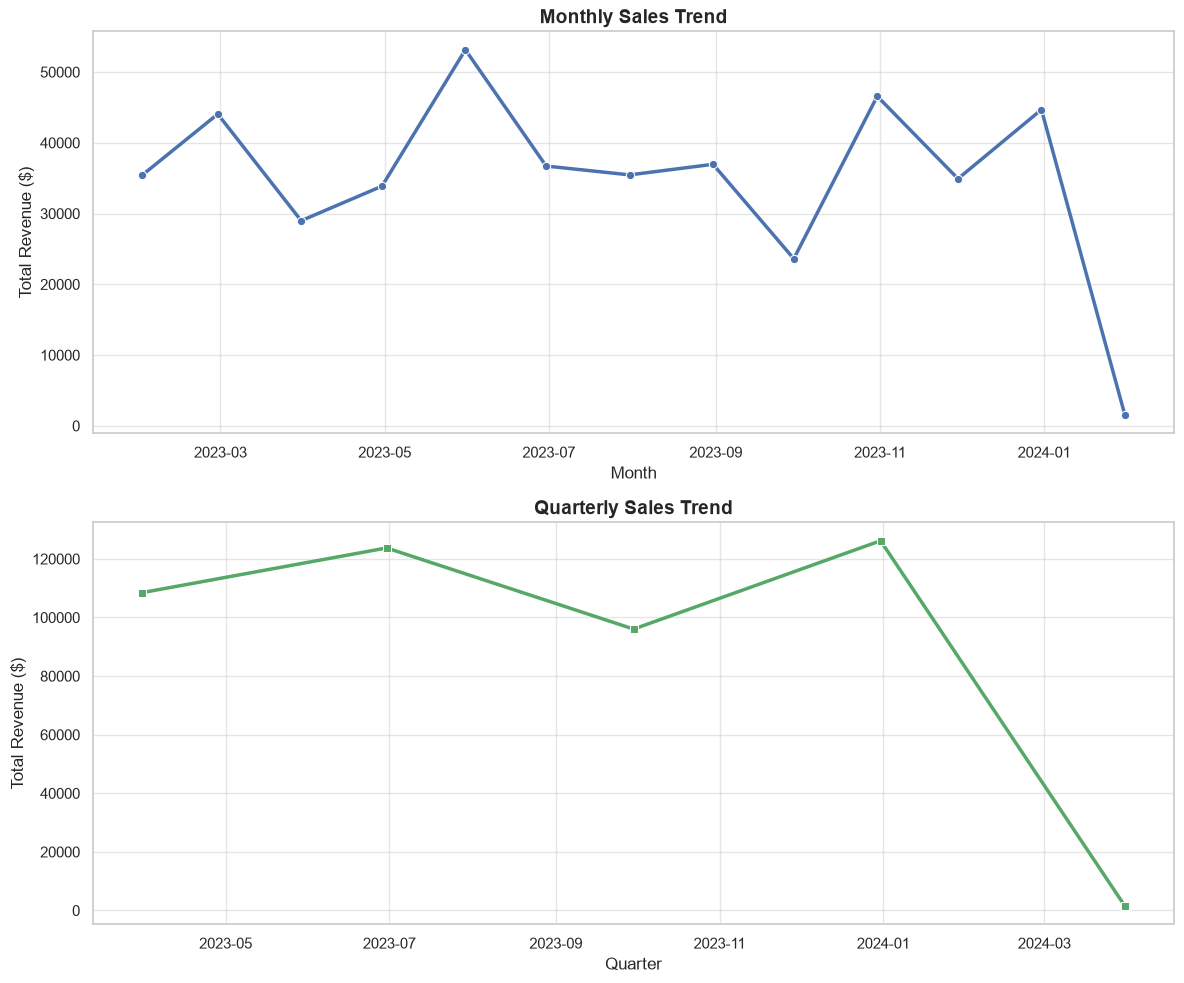

In [9]:
# 3. Time Series Analysis (Monthly and Quarterly Sales Trends)

# Set Date as index for resampling
df_time = df.set_index('Date')

# Monthly Sales Resampling
monthly_sales = df_time['Total Amount'].resample('ME').sum().reset_index()

# Quarterly Sales Resampling
quarterly_sales = df_time['Total Amount'].resample('QE').sum().reset_index()

# Create subplots for Monthly and Quarterly trends
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly Sales Trend
sns.lineplot(data=monthly_sales, x='Date', y='Total Amount', ax=axes[0], marker='o', color='b', linewidth=2.5)
axes[0].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Total Revenue ($)', fontsize=12)

# Plot 2: Quarterly Sales Trend
sns.lineplot(data=quarterly_sales, x='Date', y='Total Amount', ax=axes[1], marker='s', color='g', linewidth=2.5)
axes[1].set_title('Quarterly Sales Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter', fontsize=12)
axes[1].set_ylabel('Total Revenue ($)', fontsize=12)

plt.tight_layout()
plt.show()

### Time Series Analysis Observations
- Monthly Fluctuations: Sales revenue exhibits periodic spikes and dips throughout the year, indicating potential seasonality in customer purchasing behavior.
- Quarterly Performance: The quarterly aggregate trend highlights peak performance periods, providing clearer visibility for quarterly inventory planning and budget allocation.

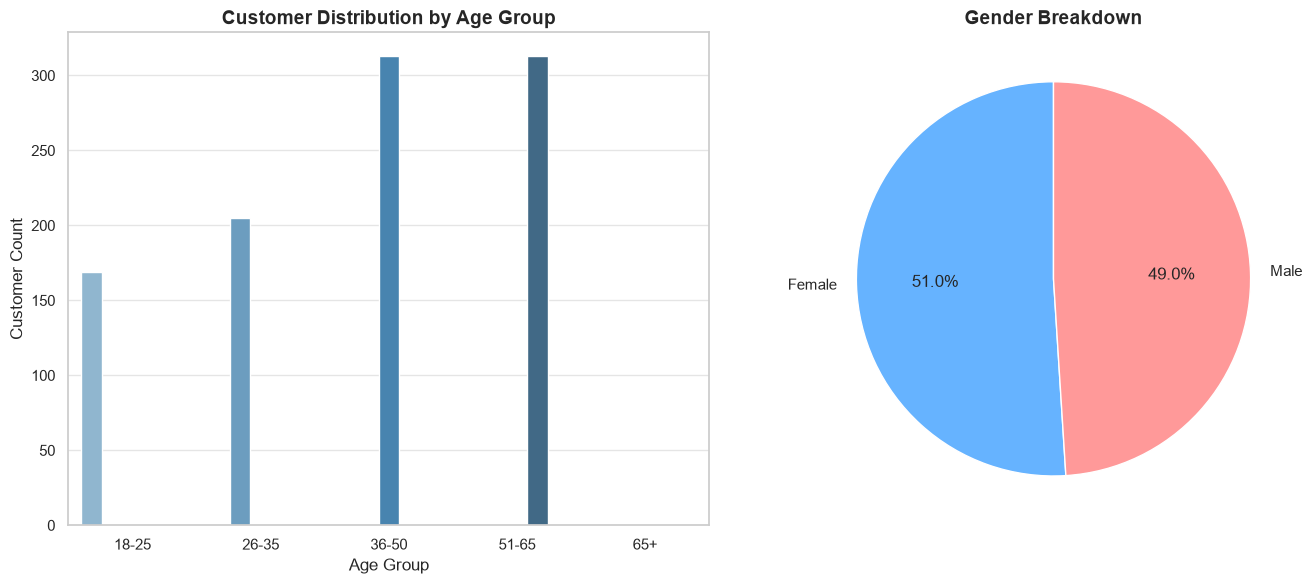

In [10]:
# 4. Customer Demographics Analysis (Age Groups & Gender Breakdown)

# Create age group bins
age_bins = [17, 25, 35, 50, 65, 100]
age_labels = ['18-25', '26-35', '36-50', '51-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Age Group Distribution
sns.countplot(data=df, x='Age Group', ax=axes[0], palette='Blues_d', hue='Age Group', legend=False)
axes[0].set_title('Customer Distribution by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Customer Count', fontsize=12)

# Plot 2: Gender Breakdown
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
axes[1].set_title('Gender Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Customer Demographics Observations
- Age Distribution: Customers are spread across various age brackets, with significant representation across the 26–50 age groups, helping guide target audience selection for promotional campaigns.
- Gender Breakdown: The customer base shows a balanced distribution between male and female shoppers, indicating equal market penetration across both genders.

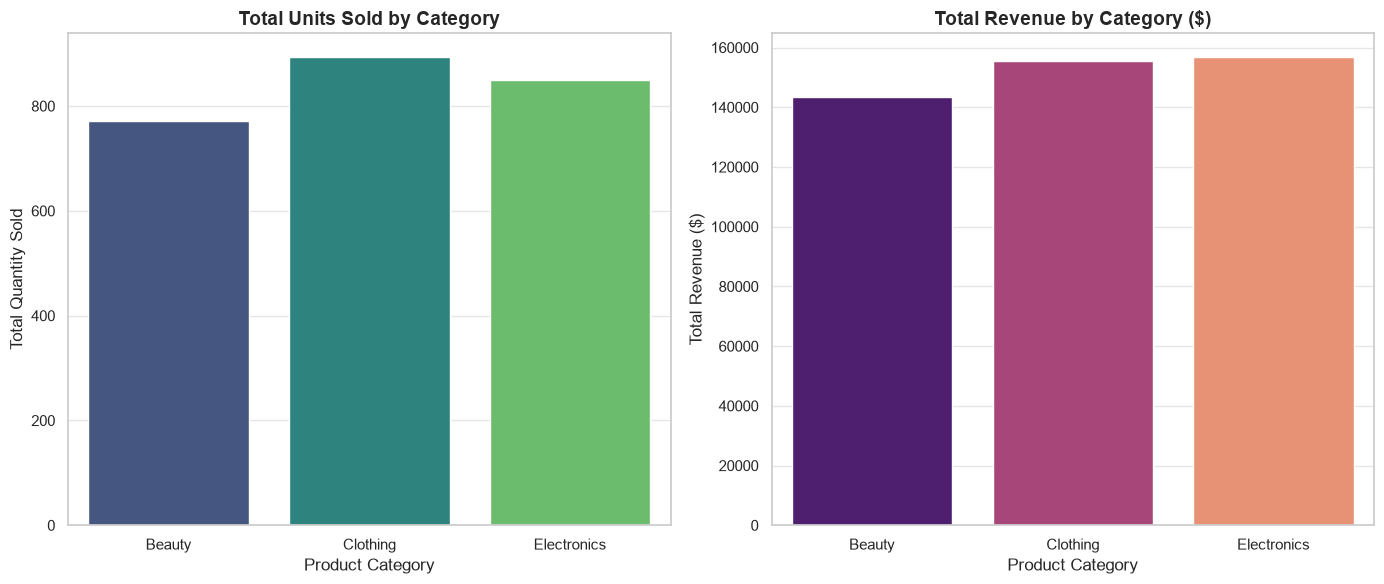

In [11]:
# 5. Product Analysis (Sales & Revenue by Category)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Total Units Sold by Product Category
category_qty = df.groupby('Product Category')['Quantity'].sum().reset_index()
sns.barplot(data=category_qty, x='Product Category', y='Quantity', ax=axes[0], palette='viridis', hue='Product Category', legend=False)
axes[0].set_title('Total Units Sold by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category', fontsize=12)
axes[0].set_ylabel('Total Quantity Sold', fontsize=12)

# Plot 2: Total Revenue by Product Category
category_rev = df.groupby('Product Category')['Total Amount'].sum().reset_index()
sns.barplot(data=category_rev, x='Product Category', y='Total Amount', ax=axes[1], palette='magma', hue='Product Category', legend=False)
axes[1].set_title('Total Revenue by Category ($)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category', fontsize=12)
axes[1].set_ylabel('Total Revenue ($)', fontsize=12)

plt.tight_layout()
plt.show()

### Product Analysis Observations
- Top Generating Categories: The revenue distribution across categories (such as Electronics, Clothing, and Beauty) shows consistent demand, highlighting key revenue-generating streams.
- Sales vs. Revenue Correlation: Comparing unit volume to total revenue confirms which product lines deliver higher profit margins per item sold.

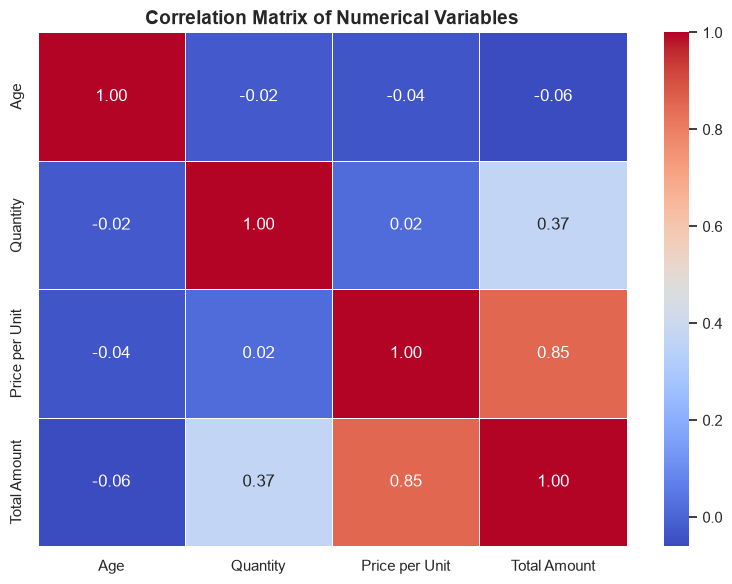

In [12]:
# 6. Correlation Matrix Heatmap

plt.figure(figsize=(8, 6))

# Select numerical columns for correlation
num_df = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]
corr_matrix = num_df.corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Correlation Heatmap Observations
- Key Relationships: Total Amount displays a strong positive correlation with Quantity and Price per Unit, as expected logically.
- Demographic Independence: Customer Age shows minimal to no strong correlation with order values or quantity, suggesting that purchasing spend is uniform across age groups.

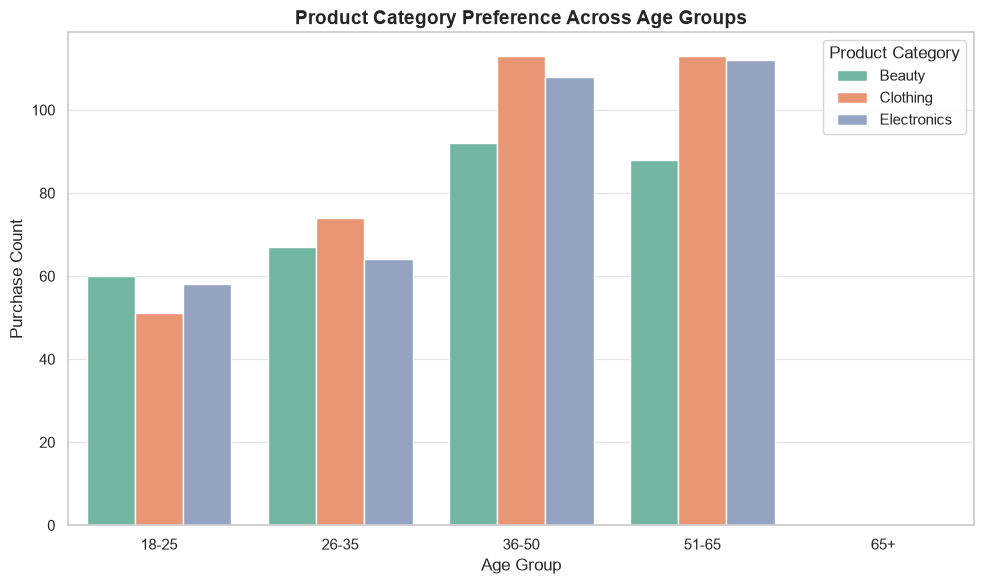

In [13]:
# 7. Additional Insight: Preferred Product Category by Age Group

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age Group', hue='Product Category', palette='Set2')
plt.title('Product Category Preference Across Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Purchase Count', fontsize=12)
plt.legend(title='Product Category')

plt.tight_layout()
plt.show()

## Conclusion & Actionable Business Recommendations

Based on the Exploratory Data Analysis (EDA) performed on the retail sales dataset, here are three strategic recommendations for business growth:

1. Targeted Age-Based Marketing Campaigns:
   - Insight: Sales are steady across middle-aged demographics (26–50), but specific product preferences vary.
   - Action: Design targeted marketing strategies on social media tailored to age group preferences (e.g., promoting Electronics and Beauty products specifically to high-engaging age brackets).

2. Inventory & Seasonal Stock Optimization:
   - Insight: Time series analysis reveals fluctuations in sales revenue throughout different months and quarters.
   - Action: Align inventory supply chains with quarterly peak sales cycles to avoid stockouts during high-demand months and minimize holding costs during slower periods.

3. Product Bundling and Cross-Selling:
   - Insight: Units sold per transaction average around specific standard price points ($50).
   - Action: Introduce promotional product bundles (e.g., pairing Beauty items with Clothing or Electronics) at discounted bundle rates to increase the average order value (AOV) per transaction.